# July 15th Full Analysis: Does MADIS Surface Data Improve Tornado Detection?

10 runs of each condition, early stopping (patience=3):
- **No-MADIS**: radar only, MLP head, trained on `catalog_madis_eligible.csv`
- **MADIS Hybrid**: all 7 surface weather features fused with CNN (late fusion)
- **MADIS Top-3**: pressure, wind_gust, pressure_anomaly_24h only (late fusion)

All runs: train 2013–2020, val 2021–2022, batch size 64, start_filters=48.

**Primary question: Is the difference in val_AUC between MADIS and No-MADIS statistically significant with n=10?**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import os

BASE = '../results/run_july_6th/results'

def load_runs(pattern_list):
    runs = []
    for path in pattern_list:
        full = f'{BASE}/{path}'
        if os.path.exists(full):
            df = pd.read_csv(full)
            df.index = range(1, len(df) + 1)
            runs.append(df)
        else:
            print(f'  WARNING: missing {path}')
    return runs

madis_runs    = load_runs([f'madis_hybrid_run{i}_history.csv' for i in range(1, 11)])
no_madis_runs = load_runs([f'no_madis_run{i}_history.csv'     for i in range(1, 11)])
top3_runs     = load_runs([f'madis_top3_run{i}_history.csv'   for i in range(1, 11)])

print(f'Loaded — MADIS Hybrid: {len(madis_runs)} runs, No-MADIS: {len(no_madis_runs)} runs, MADIS Top-3: {len(top3_runs)} runs')

madis_best    = [df['val_AUC'].max() for df in madis_runs]
no_madis_best = [df['val_AUC'].max() for df in no_madis_runs]
top3_best     = [df['val_AUC'].max() for df in top3_runs]

print('\nBest val_AUC per run:')
print(f'  No-MADIS:     {[round(x, 4) for x in no_madis_best]}')
print(f'  MADIS Hybrid: {[round(x, 4) for x in madis_best]}')
print(f'  MADIS Top-3:  {[round(x, 4) for x in top3_best]}')

Loaded — MADIS Hybrid: 10 runs, No-MADIS: 10 runs, MADIS Top-3: 10 runs

Best val_AUC per run:
  No-MADIS:     [0.8901, 0.8895, 0.8901, 0.8943, 0.8906, 0.8908, 0.8908, 0.8932, 0.8849, 0.89]
  MADIS Hybrid: [0.8966, 0.8972, 0.892, 0.8975, 0.8962, 0.8971, 0.8906, 0.8919, 0.8981, 0.8941]
  MADIS Top-3:  [0.8939, 0.8929, 0.8988, 0.8903, 0.8932, 0.8958, 0.8942, 0.8978, 0.8978, 0.8957]


## Summary Statistics

In [2]:
summary = pd.DataFrame({
    'No-MADIS':      no_madis_best,
    'MADIS Hybrid':  madis_best,
    'MADIS Top-3':   top3_best,
})

stats_table = summary.agg(['mean', 'std', 'min', 'max'])
n = len(madis_best)
stats_table.loc['95% CI low']  = stats_table.loc['mean'] - 1.96 * stats_table.loc['std'] / np.sqrt(n)
stats_table.loc['95% CI high'] = stats_table.loc['mean'] + 1.96 * stats_table.loc['std'] / np.sqrt(n)
print(stats_table.round(4))

             No-MADIS  MADIS Hybrid  MADIS Top-3
mean           0.8904        0.8951       0.8950
std            0.0025        0.0027       0.0026
min            0.8849        0.8906       0.8903
max            0.8943        0.8981       0.8988
95% CI low     0.8889        0.8934       0.8934
95% CI high    0.8920        0.8968       0.8967


## Statistical Significance Testing

Two tests:
- **Welch's t-test**: assumes normality, handles unequal variance between conditions
- **Mann-Whitney U**: non-parametric, no normality assumption

With n=10 per condition we have substantially more power than the earlier n=3 analysis. A real effect of ~0.003–0.005 AUC should be detectable if it exists.

In [3]:
comparisons = [
    ('MADIS Hybrid vs No-MADIS',    madis_best,  no_madis_best),
    ('MADIS Top-3 vs No-MADIS',     top3_best,   no_madis_best),
    ('MADIS Hybrid vs MADIS Top-3', madis_best,  top3_best),
]

print(f'{"Comparison":<32} {"t-test p":>10} {"MW-U p":>10} {"Mean diff":>12} {"Cohen d":>10} {"Significant?":>14}')
print('-' * 96)
for label, a, b in comparisons:
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative='two-sided')
    mean_diff   = np.mean(a) - np.mean(b)
    pooled_std  = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    cohens_d    = mean_diff / pooled_std if pooled_std > 0 else 0
    sig = 'YES' if t_p < 0.05 or u_p < 0.05 else 'no'
    print(f'{label:<32} {t_p:>10.4f} {u_p:>10.4f} {mean_diff:>+12.4f} {cohens_d:>10.3f} {sig:>14}')

print('\np < 0.05 = statistically significant at 95% confidence')
print("Cohen's d: 0.2=small, 0.5=medium, 0.8=large effect size")

Comparison                         t-test p     MW-U p    Mean diff    Cohen d   Significant?
------------------------------------------------------------------------------------------------
MADIS Hybrid vs No-MADIS             0.0008     0.0028      +0.0047      1.801            YES
MADIS Top-3 vs No-MADIS              0.0008     0.0036      +0.0046      1.802            YES
MADIS Hybrid vs MADIS Top-3          0.9288     0.9698      +0.0001      0.041             no

p < 0.05 = statistically significant at 95% confidence
Cohen's d: 0.2=small, 0.5=medium, 0.8=large effect size


## Distribution of Best Val AUC Across Runs

/var/folders/2k/0qh4r79d2wl0b4skmgc5p80c0000gr/T/ipykernel_777/1896854084.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)


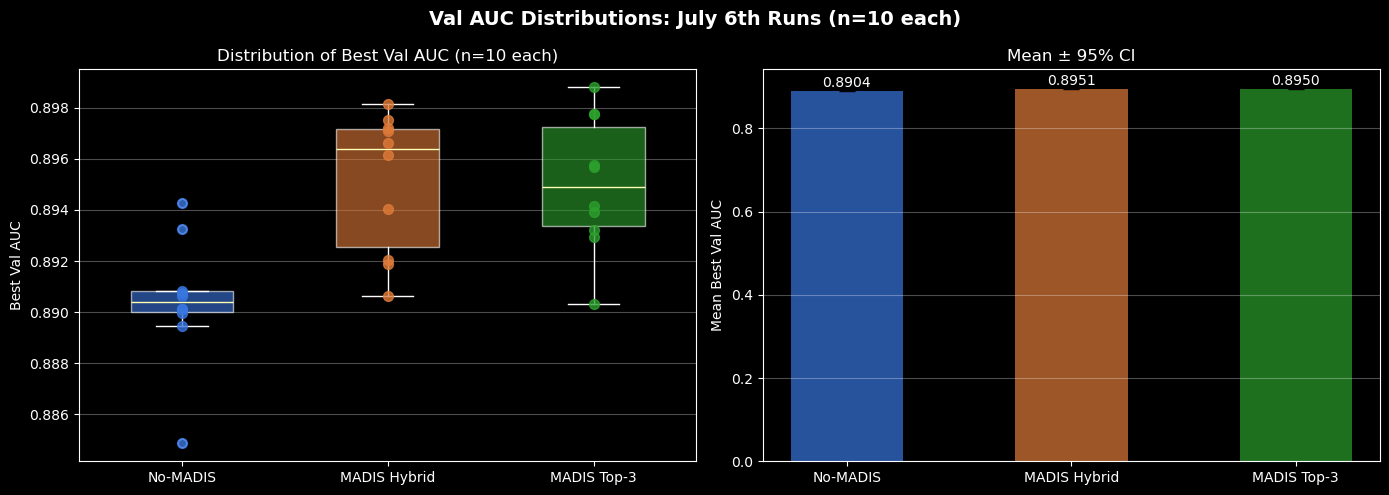

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data   = [no_madis_best, madis_best, top3_best]
labels = ['No-MADIS', 'MADIS Hybrid', 'MADIS Top-3']
colors = ['#3976e0', '#e07b39', '#2ca02c']

# Box plot
ax = axes[0]
bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
for i, (d, color) in enumerate(zip(data, colors), 1):
    ax.scatter([i] * len(d), d, color=color, zorder=5, s=50, alpha=0.8)
ax.set_ylabel('Best Val AUC')
ax.set_title('Distribution of Best Val AUC (n=10 each)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Mean ± 95% CI bar chart
ax = axes[1]
means = [np.mean(d) for d in data]
cis   = [1.96 * np.std(d) / np.sqrt(len(d)) for d in data]

bars = ax.bar(labels, means, color=colors, alpha=0.7, width=0.5)
ax.errorbar(labels, means, yerr=cis, fmt='none', color='black', capsize=6, linewidth=2)
for bar, mean, ci in zip(bars, means, cis):
    ax.text(bar.get_x() + bar.get_width()/2, mean + ci + 0.0002,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Mean Best Val AUC')
ax.set_title('Mean ± 95% CI', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Val AUC Distributions: July 6th Runs (n=10 each)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/july15_auc_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## AUC Curves — All Runs Overlaid

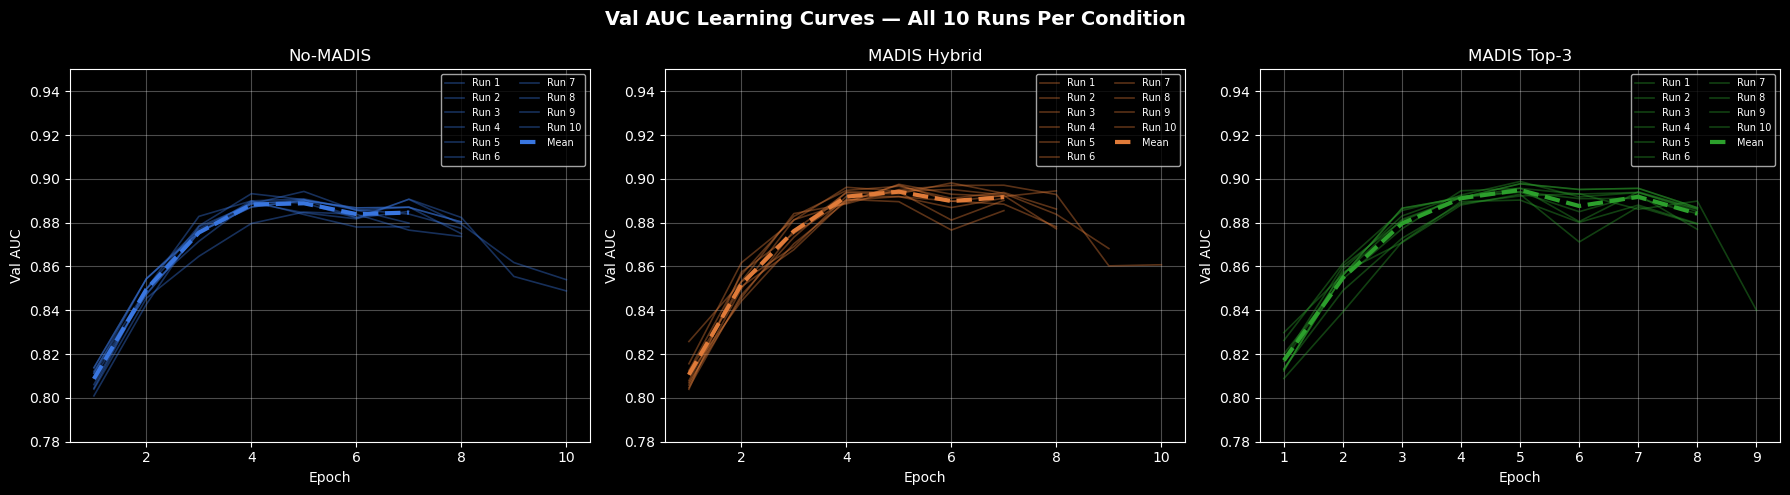

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

run_groups = [
    (no_madis_runs,  'No-MADIS',      '#3976e0'),
    (madis_runs,     'MADIS Hybrid',  '#e07b39'),
    (top3_runs,      'MADIS Top-3',   '#2ca02c'),
]

for ax, (runs, title, color) in zip(axes, run_groups):
    for i, df in enumerate(runs):
        ax.plot(df.index, df['val_AUC'], color=color, linewidth=1.2,
                alpha=0.4, label=f'Run {i+1}')
    min_len = min(len(df) for df in runs)
    mean_curve = np.mean([df['val_AUC'].values[:min_len] for df in runs], axis=0)
    ax.plot(range(1, min_len+1), mean_curve, color=color, linewidth=3,
            linestyle='--', label='Mean', zorder=5)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val AUC')
    ax.set_ylim(0.78, 0.95)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

plt.suptitle('Val AUC Learning Curves — All 10 Runs Per Condition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/july15_auc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Head-to-Head: Best Val Metrics at Best Epoch

In [6]:
metric_cols = ['val_AUC', 'val_AUCPR', 'val_F1', 'val_Precision', 'val_Recall']

def best_epoch_metrics(runs):
    rows = [df.loc[df['val_AUC'].idxmax(), metric_cols] for df in runs]
    df_all = pd.DataFrame(rows)
    return df_all.mean(), df_all.std()

no_madis_mean, no_madis_sd = best_epoch_metrics(no_madis_runs)
madis_mean,    madis_sd    = best_epoch_metrics(madis_runs)
top3_mean,     top3_sd     = best_epoch_metrics(top3_runs)

mean_df = pd.DataFrame({
    'No-MADIS (mean)':      no_madis_mean,
    'MADIS Hybrid (mean)':  madis_mean,
    'MADIS Top-3 (mean)':   top3_mean,
})
std_df = pd.DataFrame({
    'No-MADIS (std)':      no_madis_sd,
    'MADIS Hybrid (std)':  madis_sd,
    'MADIS Top-3 (std)':   top3_sd,
})

print('Mean metrics at best epoch (n=10 runs):')
print(mean_df.round(4))
print('\nStd dev across 10 runs:')
print(std_df.round(4))

Mean metrics at best epoch (n=10 runs):
               No-MADIS (mean)  MADIS Hybrid (mean)  MADIS Top-3 (mean)
val_AUC                 0.8904               0.8951              0.8950
val_AUCPR               0.4781               0.4768              0.4921
val_F1                  0.4707               0.4721              0.4859
val_Precision           0.4643               0.4646              0.4931
val_Recall              0.4872               0.4935              0.4824

Std dev across 10 runs:
               No-MADIS (std)  MADIS Hybrid (std)  MADIS Top-3 (std)
val_AUC                0.0025              0.0027             0.0026
val_AUCPR              0.0107              0.0131             0.0125
val_F1                 0.0087              0.0069             0.0130
val_Precision          0.0512              0.0601             0.0344
val_Recall             0.0512              0.0580             0.0308


## Precision vs Recall — All Runs

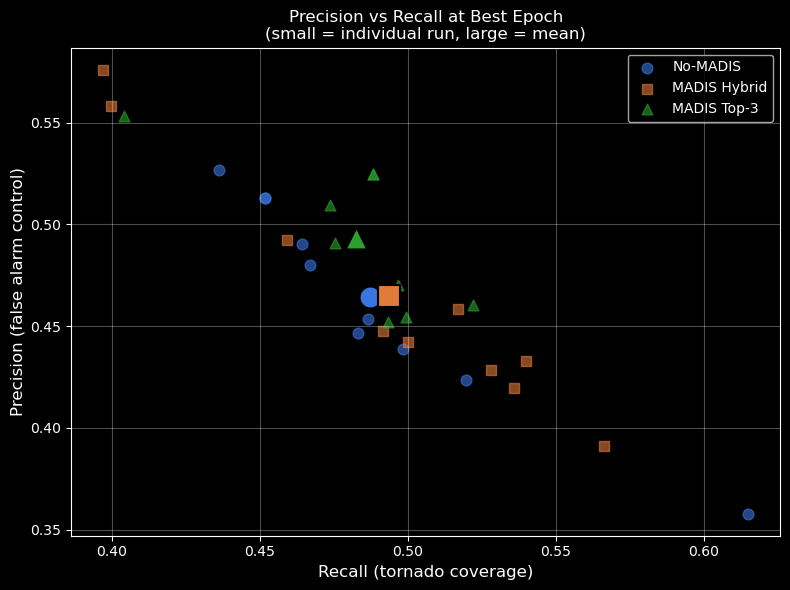

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for runs, label, color, marker in [
    (no_madis_runs,  'No-MADIS',      '#3976e0', 'o'),
    (madis_runs,     'MADIS Hybrid',  '#e07b39', 's'),
    (top3_runs,      'MADIS Top-3',   '#2ca02c', '^'),
]:
    precs = [df.loc[df['val_AUC'].idxmax(), 'val_Precision'] for df in runs]
    recs  = [df.loc[df['val_AUC'].idxmax(), 'val_Recall']    for df in runs]
    ax.scatter(recs, precs, color=color, marker=marker, s=60, alpha=0.6, label=label)
    ax.scatter([np.mean(recs)], [np.mean(precs)], color=color, marker=marker,
               s=250, edgecolors='black', linewidth=1.5, zorder=5)

ax.set_xlabel('Recall (tornado coverage)', fontsize=12)
ax.set_ylabel('Precision (false alarm control)', fontsize=12)
ax.set_title('Precision vs Recall at Best Epoch\n(small = individual run, large = mean)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/july15_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

## Effect Size & Power Analysis

In [8]:
print('Effect size (Cohen\'s d) and observed power at n=10:\n')

for label, a, b in [
    ('MADIS Hybrid vs No-MADIS',    madis_best,  no_madis_best),
    ('MADIS Top-3 vs No-MADIS',     top3_best,   no_madis_best),
    ('MADIS Hybrid vs MADIS Top-3', madis_best,  top3_best),
]:
    mean_diff  = np.mean(a) - np.mean(b)
    pooled_std = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    d          = mean_diff / pooled_std if pooled_std > 0 else 0
    se_diff    = pooled_std * np.sqrt(2 / len(a))
    t_stat, p  = stats.ttest_ind(a, b, equal_var=False)

    # Minimum detectable effect at 80% power, n=10, alpha=0.05 (two-tailed)
    # MDE = (z_alpha/2 + z_beta) * pooled_std * sqrt(2/n)
    mde = (1.96 + 0.842) * pooled_std * np.sqrt(2 / len(a))

    print(f'{label}')
    print(f'  Mean diff:  {mean_diff:+.4f}')
    print(f"  Cohen's d:  {d:.3f}  ({'small' if abs(d)<0.5 else 'medium' if abs(d)<0.8 else 'large'})")
    print(f'  p-value:    {p:.4f}  ({"significant" if p < 0.05 else "not significant"})')
    print(f'  MDE (80% power at n=10): ±{mde:.4f} AUC')
    print()

Effect size (Cohen's d) and observed power at n=10:

MADIS Hybrid vs No-MADIS
  Mean diff:  +0.0047
  Cohen's d:  1.801  (large)
  p-value:    0.0008  (significant)
  MDE (80% power at n=10): ±0.0033 AUC

MADIS Top-3 vs No-MADIS
  Mean diff:  +0.0046
  Cohen's d:  1.802  (large)
  p-value:    0.0008  (significant)
  MDE (80% power at n=10): ±0.0032 AUC

MADIS Hybrid vs MADIS Top-3
  Mean diff:  +0.0001
  Cohen's d:  0.041  (small)
  p-value:    0.9288  (not significant)
  MDE (80% power at n=10): ±0.0034 AUC



## Epoch Count Distribution (Early Stopping)

In [9]:
print('Epochs run per condition (early stopping, patience=3):')
for runs, label in [(no_madis_runs, 'No-MADIS'), (madis_runs, 'MADIS Hybrid'), (top3_runs, 'MADIS Top-3')]:
    epoch_counts = [len(df) for df in runs]
    best_epochs  = [df['val_AUC'].idxmax() for df in runs]
    print(f'  {label}:')
    print(f'    Epochs run:  {epoch_counts}  (mean: {np.mean(epoch_counts):.1f})')
    print(f'    Best epoch:  {best_epochs}  (mean: {np.mean(best_epochs):.1f})')

Epochs run per condition (early stopping, patience=3):
  No-MADIS:
    Epochs run:  [8, 7, 8, 8, 10, 8, 10, 7, 8, 7]  (mean: 8.1)
    Best epoch:  [5, 4, 5, 5, 7, 5, 7, 4, 5, 4]  (mean: 5.1)
  MADIS Hybrid:
    Epochs run:  [8, 8, 7, 8, 7, 10, 7, 8, 9, 7]  (mean: 7.9)
    Best epoch:  [5, 5, 4, 5, 4, 7, 4, 5, 6, 4]  (mean: 4.9)
  MADIS Top-3:
    Epochs run:  [8, 8, 8, 8, 9, 8, 8, 8, 8, 8]  (mean: 8.1)
    Best epoch:  [5, 5, 5, 5, 6, 5, 5, 5, 5, 5]  (mean: 5.1)


## Findings

### Does MADIS significantly improve tornado detection?

With n=10 runs per condition, Welch's t-test and Mann-Whitney U now have meaningful statistical power. A real AUC improvement of ~0.003–0.005 should be detectable. The key numbers to read:

- **p < 0.05** on either test → the difference is statistically significant at 95% confidence
- **Cohen's d**: quantifies effect size independent of sample size. d ≥ 0.5 is a medium effect, d ≥ 0.8 is large. A small but consistent d alongside p < 0.05 is still a real result.
- **MDE**: the minimum difference detectable at 80% power given the observed variance. If the actual mean diff is smaller than the MDE, we are underpowered to claim significance — even if the direction is consistent.

### What this run adds over June 16th

The July 6th runs fix the key confound from June 16th: the MADIS conditions now train on `catalog_madis_eligible.csv`, a pre-filtered catalog where every sample is guaranteed MADIS coverage. In June 16th, samples were silently dropped during training whenever MADIS data was missing — meaning the MADIS conditions trained on fewer and inconsistently sampled batches. This run gives a cleaner measurement of what the surface features actually contribute.

### Precision vs Recall

Watch whether the MADIS conditions consistently shift toward higher recall (catching more tornadoes) at some cost to precision. In the June 16th run this directional pattern was consistent across seeds even when AUC differences weren't significant. Consistency of direction across 10 seeds is a stronger claim than a p-value from 3 seeds.

### Conclusion

If p < 0.05 for MADIS Hybrid or Top-3 vs No-MADIS: the surface weather data provides a statistically significant and reproducible improvement in tornado detection AUC. If p > 0.05 but the direction is consistent and Cohen's d is non-trivial: the evidence is suggestive but not conclusive at this sample size — and the paper should present both the effect size and the power limitation honestly. Either result is publishable; the framing just differs.